# Statistical Analysis — AG2 Stage 2 Interventions

Paired statistical tests comparing each Stage 2 intervention against the Stage 1 baseline on the same OlympiadBench tasks.

**Statistical methods:**
- **McNemar test** (paired binary, applied to accuracy and every FM): exact binomial when b+c < 25; χ² with continuity correction otherwise
- **Bootstrap 95% CI**: 10 000 paired resamples keyed on `question_id`, seed = 42

In [151]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
from IPython.display import display

# make AG2/paths.py importable (this notebook lives in AG2/analysis/)
sys.path.insert(0, str(Path('..').resolve()))
import paths

## Configuration

In [152]:
RESULTS = paths.RESULTS_DIR

BASELINE = RESULTS / 'baseline_olympiad_gpt41_n50_20260609'

INTERVENTIONS = [
    (
        'v1 - FM-2.6 Action-Reasoning Mismatch',
        RESULTS / 'stage_2_v1_olympiad_gpt41_n50_20260611',
        '2.6',
    ),
    (
        'v2 - FM-1.1 Disobey Task Specification',
        RESULTS / 'stage_2_v2_olympiad_gpt41_n50_20260612',
        '1.1',
    ),
    (
        'v3 - FM-3.3 Weak Verification',
        RESULTS / 'stage_2_v3_olympiad_gpt41_n50_20260613',
        '3.3',
    ),
]

FM_CODES = [
    '1.1', '1.2', '1.3', '1.4', '1.5',
    '2.1', '2.2', '2.3', '2.4', '2.5', '2.6',
    '3.1', '3.2', '3.3',
]

FM_NAMES = {
    '1.1': 'Disobey Task Specification',
    '1.2': 'Disobey Role Specification',
    '1.3': 'Step Repetition',
    '1.4': 'Loss of Conversation History',
    '1.5': 'Unaware of Termination Conditions',
    '2.1': 'Conversation Reset',
    '2.2': 'Fail to Ask for Clarification',
    '2.3': 'Task Derailment',
    '2.4': 'Information Withholding',
    '2.5': "Ignored Other Agent's Input",
    '2.6': 'Action-Reasoning Mismatch',
    '3.1': 'Premature Termination',
    '3.2': 'No or Incorrect Verification',
    '3.3': 'Weak Verification',
}

## Data Loading

In [153]:
def load_run(run_dir: Path, label: str) -> pd.DataFrame:
    pred = pd.read_csv(run_dir / paths.JUDGE_SUBDIR / 'predictions.csv')
    summ = pd.read_csv(run_dir / 'summary.csv')[['trace_id', 'question_id', 'correct']]
    # Robustly parse correct column regardless of bool/string encoding
    summ['correct'] = (
        summ['correct']
        .map({'True': True, 'False': False, True: True, False: False})
        .astype(bool)
    )
    df = pred.merge(summ, on='trace_id', how='left')
    df['_run'] = label
    return df


df_base = load_run(BASELINE, 'Baseline')
print(f'Baseline : {len(df_base):3d} traces  |  accuracy = {df_base["correct"].mean():.3f}')
print()
for label, idir, fm in INTERVENTIONS:
    df_i = load_run(idir, label)
    print(f'{label}')
    print(f'  {len(df_i):3d} traces  |  accuracy = {df_i["correct"].mean():.3f}  |  target FM-{fm} prevalence = {df_i[fm].mean():.3f}')

Baseline :  49 traces  |  accuracy = 0.653

v1 - FM-2.6 Action-Reasoning Mismatch
   49 traces  |  accuracy = 0.633  |  target FM-2.6 prevalence = 0.265
v2 - FM-1.1 Disobey Task Specification
   48 traces  |  accuracy = 0.708  |  target FM-1.1 prevalence = 0.125
v3 - FM-3.3 Weak Verification
   49 traces  |  accuracy = 0.694  |  target FM-3.3 prevalence = 0.184


In [154]:
runs_overview = [
    ('Baseline',      df_base),
    ('Int 1  FM-1.1', load_run(INTERVENTIONS[1][1], 'int1')),
    ('Int 2  FM-3.3', load_run(INTERVENTIONS[2][1], 'int2')),
    ('Int 3  FM-2.6', load_run(INTERVENTIONS[0][1], 'int3')),
]

rows = []
for label, df in runs_overview:
    has_fm = df[FM_CODES].any(axis=1)
    rows.append({
        'Run'              : label,
        'Traces with >= 1 FM': f'{has_fm.sum()}/{len(df)}',
        '%'                : round(has_fm.mean() * 100, 1),
    })

display(
    pd.DataFrame(rows).style
    .hide(axis='index')
    .format({'%': '{:.1f}%'})
    .set_caption('Traces with at least one FM flagged')
    .set_properties(**{'text-align': 'right'}, subset=['Traces with >= 1 FM', '%'])
    .set_properties(**{'text-align': 'left'}, subset=['Run'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
    ])
)

Run,Traces with >= 1 FM,%
Baseline,23/49,46.9%
Int 1 FM-1.1,17/48,35.4%
Int 2 FM-3.3,16/49,32.7%
Int 3 FM-2.6,19/49,38.8%


## Pairing & Statistical Functions

In [155]:
def pair_runs(df_left: pd.DataFrame, df_right: pd.DataFrame) -> pd.DataFrame:
    """Inner join on question_id → one row per shared task."""
    left  = df_left.set_index('question_id')
    right = df_right.set_index('question_id')
    paired = left.merge(
        right, left_index=True, right_index=True, suffixes=('_base', '_int')
    )
    return paired.reset_index()

In [156]:
def mcnemar_test(base_bin: np.ndarray, int_bin: np.ndarray):
    """
    McNemar test for paired binary outcomes.

    For accuracy:  base=1 means baseline correct,  int=1 means intervention correct.
    For FM columns: base=1 means FM present in baseline, int=1 means FM present in intervention.

    Returns (b, c, statistic, p_value, method):
      b = base=1 & int=0
      c = base=0 & int=1
    Uses exact binomial when b+c < 25, chi-square with continuity correction otherwise.
    """
    x = base_bin.astype(int)
    y = int_bin.astype(int)
    b = int(((x == 1) & (y == 0)).sum())
    c = int(((x == 0) & (y == 1)).sum())
    n = b + c
    if n == 0:
        return b, c, np.nan, np.nan, '—'
    if n < 25:
        p = stats.binomtest(min(b, c), n=n, p=0.5, alternative='two-sided').pvalue
        return b, c, float(min(b, c)), float(p), 'exact binomial'
    stat = (abs(b - c) - 1) ** 2 / n
    p = stats.chi2.sf(stat, df=1)
    return b, c, float(stat), float(p), 'χ² (CC)'


def bootstrap_ci(
    base_vals: np.ndarray,
    int_vals: np.ndarray,
    n_boot: int = 10_000,
    seed: int = 42,
):
    """Paired bootstrap 95% CI on mean(intervention) − mean(baseline)."""
    n   = len(base_vals)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_diffs = int_vals[idx].mean(axis=1) - base_vals[idx].mean(axis=1)
    return float(np.percentile(boot_diffs, 2.5)), float(np.percentile(boot_diffs, 97.5))

## Table Building & Display Helpers

In [157]:
def _fmt_p(p: float) -> str:
    if np.isnan(p):
        return '—'
    if p < 0.001:
        return '< 0.001'
    return f'{p:.3f}'


def _fmt_ci(lo: float, hi: float) -> str:
    def _s(v):
        pp = v * 100
        return f'+{pp:.1f}pp' if pp >= 0 else f'{pp:.1f}pp'
    return f'[{_s(lo)}, {_s(hi)}]'


def _fmt_diff(d: float) -> str:
    pp = d * 100
    return f'+{pp:.1f}pp' if pp >= 0 else f'{pp:.1f}pp'


def build_summary_table(int_dir: Path, target_fm: str) -> pd.DataFrame:
    """Return a 15-row summary DataFrame for one intervention vs baseline."""
    df_int = load_run(int_dir, 'Intervention')
    paired = pair_runs(df_base, df_int)
    n_paired = len(paired)

    rows = []

    # ── Accuracy ─────────────────────────────────────────────────────────────
    bv = paired['correct_base'].astype(float).values
    iv = paired['correct_int'].astype(float).values
    b, c, stat, p, method = mcnemar_test(bv, iv)
    ci_lo, ci_hi = bootstrap_ci(bv, iv)
    rows.append({
        'Metric'      : 'Accuracy',
        'Baseline'    : f'{bv.mean():.3f}',
        'Intervention': f'{iv.mean():.3f}',
        'Difference'  : _fmt_diff(iv.mean() - bv.mean()),
        '95% CI'      : _fmt_ci(ci_lo, ci_hi),
        'p-value'     : _fmt_p(p),
        'Method'      : method,
        '_target'     : False,
        '_n_paired'   : n_paired,
    })

    # ── FM rows ───────────────────────────────────────────────────────────────
    for fm in FM_CODES:
        bv = paired[f'{fm}_base'].astype(float).values
        iv = paired[f'{fm}_int'].astype(float).values
        b, c, stat, p, method = mcnemar_test(bv, iv)
        ci_lo, ci_hi = bootstrap_ci(bv, iv)
        rows.append({
            'Metric'      : f'FM {fm}  {FM_NAMES[fm]}',
            'Baseline'    : f'{bv.mean():.3f}',
            'Intervention': f'{iv.mean():.3f}',
            'Difference'  : _fmt_diff(iv.mean() - bv.mean()),
            '95% CI'      : _fmt_ci(ci_lo, ci_hi),
            'p-value'     : _fmt_p(p),
            'Method'      : method,
            '_target'     : fm == target_fm,
            '_n_paired'   : n_paired,
        })

    return pd.DataFrame(rows)


def display_summary(df: pd.DataFrame, title: str) -> None:
    n = int(df['_n_paired'].iloc[0])

    vis_cols = ['Metric', 'Baseline', 'Intervention', 'Δ (pp)', '95% CI', 'p-value']
    df = df.rename(columns={'Difference': 'Δ (pp)'}).copy()

    def _highlight(row):
        if row['_target']:
            return ['background-color: #dbeafe; font-weight: bold'] * len(row)
        return [''] * len(row)

    styled = (
        df[vis_cols + ['_target']]
        .style
        .apply(_highlight, axis=1)
        .hide(axis='index')
        .hide(['_target'], axis='columns')
        .set_caption(f'{title}  (n = {n} paired tasks)')
        .set_properties(
            **{'text-align': 'right'},
            subset=['Baseline', 'Intervention', 'Δ (pp)', '95% CI', 'p-value'],
        )
        .set_properties(**{'text-align': 'left'}, subset=['Metric'])
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
            {'selector': 'th',
             'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
        ])
    )
    display(styled)

---
## Intervention 1: FM-1.1 Disobey Task Specification

**Prompt addition:** *"Always provide the general solution or expression requested by the task, even if a specific numerical example is used to verify the approach. Final answers must follow the requested output format exactly. Use exact symbolic forms such as fractions or radicals instead of decimal approximations unless the problem explicitly asks for decimals."*

In [158]:
v2_label, v2_dir, v2_fm = INTERVENTIONS[1]
t_v2 = build_summary_table(v2_dir, v2_fm)
display_summary(t_v2, v2_label)

Metric,Baseline,Intervention,Δ (pp),95% CI,p-value
Accuracy,0.667,0.708,+4.2pp,"[-4.2pp, +12.5pp]",0.625
FM 1.1 Disobey Task Specification,0.292,0.125,-16.7pp,"[-33.3pp, -2.1pp]",0.077
FM 1.2 Disobey Role Specification,0.021,0.000,-2.1pp,"[-6.2pp, +0.0pp]",1.000
FM 1.3 Step Repetition,0.083,0.042,-4.2pp,"[-14.6pp, +6.2pp]",0.688
FM 1.4 Loss of Conversation History,0.021,0.021,+0.0pp,"[-6.2pp, +6.2pp]",1.000
FM 1.5 Unaware of Termination Conditions,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.1 Conversation Reset,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.2 Fail to Ask for Clarification,0.062,0.021,-4.2pp,"[-12.5pp, +4.2pp]",0.625
FM 2.3 Task Derailment,0.083,0.000,-8.3pp,"[-16.7pp, -2.1pp]",0.125
FM 2.4 Information Withholding,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—


---
## Intervention 2: FM-3.3 Weak Verification

**Prompt addition:** *"After obtaining a result from code, verify the answer by substituting it back into the original problem or checking it against a known constraint before writing TERMINATE."*

In [159]:
v3_label, v3_dir, v3_fm = INTERVENTIONS[2]
t_v3 = build_summary_table(v3_dir, v3_fm)
display_summary(t_v3, v3_label)

Metric,Baseline,Intervention,Δ (pp),95% CI,p-value
Accuracy,0.667,0.708,+4.2pp,"[-6.2pp, +14.6pp]",0.688
FM 1.1 Disobey Task Specification,0.271,0.167,-10.4pp,"[-25.0pp, +4.2pp]",0.302
FM 1.2 Disobey Role Specification,0.021,0.000,-2.1pp,"[-6.2pp, +0.0pp]",1.000
FM 1.3 Step Repetition,0.062,0.042,-2.1pp,"[-8.3pp, +4.2pp]",1.000
FM 1.4 Loss of Conversation History,0.021,0.021,+0.0pp,"[-6.2pp, +6.2pp]",1.000
FM 1.5 Unaware of Termination Conditions,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.1 Conversation Reset,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.2 Fail to Ask for Clarification,0.062,0.021,-4.2pp,"[-12.5pp, +4.2pp]",0.625
FM 2.3 Task Derailment,0.083,0.000,-8.3pp,"[-16.7pp, -2.1pp]",0.125
FM 2.4 Information Withholding,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—


---
## Intervention 3: FM-2.6 Action-Reasoning Mismatch

**Prompt addition:** *"Each code block must be completely self-contained: always include all necessary imports and variable definitions, even if they appeared in a previous block. Before writing code, explicitly state what the code will compute and ensure the implementation matches that description exactly."*

In [160]:
v1_label, v1_dir, v1_fm = INTERVENTIONS[0]
t_v1 = build_summary_table(v1_dir, v1_fm)
display_summary(t_v1, v1_label)

Metric,Baseline,Intervention,Δ (pp),95% CI,p-value
Accuracy,0.653,0.633,-2.0pp,"[-12.2pp, +8.2pp]",1.000
FM 1.1 Disobey Task Specification,0.286,0.184,-10.2pp,"[-24.5pp, +4.1pp]",0.267
FM 1.2 Disobey Role Specification,0.020,0.020,+0.0pp,"[-6.1pp, +6.1pp]",1.000
FM 1.3 Step Repetition,0.082,0.041,-4.1pp,"[-14.3pp, +6.1pp]",0.688
FM 1.4 Loss of Conversation History,0.020,0.000,-2.0pp,"[-6.1pp, +0.0pp]",1.000
FM 1.5 Unaware of Termination Conditions,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.1 Conversation Reset,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.2 Fail to Ask for Clarification,0.061,0.000,-6.1pp,"[-14.3pp, +0.0pp]",0.250
FM 2.3 Task Derailment,0.082,0.000,-8.2pp,"[-16.3pp, -2.0pp]",0.125
FM 2.4 Information Withholding,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—


---
## Combined overview: all three interventions

Side-by-side comparison of all three interventions.
FMs sorted by mean absolute Δ descending.

In [161]:
def _parse_diff(s: str) -> float:
    """Parse '+8.2pp' → 0.082 for sorting in the combined table."""
    try:
        return float(s.replace('pp', '')) / 100
    except ValueError:
        return 0.0


def _fmt_pp(v: float) -> str:
    pp = v * 100
    return f'+{pp:.1f}pp' if pp >= 0 else f'{pp:.1f}pp'


def build_combined(table_triples):
    first_df = table_triples[0][2]
    metrics  = first_df['Metric'].str.replace(' ★', '', regex=False).tolist()
    n_rows   = len(metrics)

    delta_cols, numeric, target_col_pairs = [], {}, {}
    data = {'Metric': metrics}

    for i, (label, target_fm, df) in enumerate(table_triples, 1):
        short = f'Int. {i}'
        dc, pc = f'{short} Δ', f'{short} p'
        delta_cols.append(dc)
        nums = [_parse_diff(d) for d in df['Difference'].tolist()]
        numeric[dc] = nums
        data[dc] = [_fmt_pp(v) for v in nums]
        data[pc] = df['p-value'].tolist()
        target_col_pairs[target_fm] = (dc, pc)

    combined = pd.DataFrame(data)

    combined['_mean_abs'] = [
        sum(abs(numeric[dc][i]) for dc in delta_cols) / len(delta_cols)
        for i in range(n_rows)
    ]

    acc = combined.iloc[[0]]
    fms = combined.iloc[1:].copy().sort_values('_mean_abs', ascending=False)

    combined = (
        pd.concat([acc, fms])
        .reset_index(drop=True)
        .drop(columns=['_mean_abs'])
    )
    return combined, target_col_pairs


combined, target_cols = build_combined([
    (v2_label, v2_fm, t_v2),  # Int. 1 — FM-1.1
    (v3_label, v3_fm, t_v3),  # Int. 2 — FM-3.3
    (v1_label, v1_fm, t_v1),  # Int. 3 — FM-2.6
])


def _hl_combined(row):
    styles = [''] * len(row)
    col_list = list(row.index)
    for fm, (dc, pc) in target_cols.items():
        if f'FM {fm}' in row['Metric']:
            for col in ('Metric', dc, pc):
                if col in col_list:
                    styles[col_list.index(col)] = 'background-color: #dbeafe; font-weight: bold'
    return styles


styled_combined = (
    combined.style
    .apply(_hl_combined, axis=1)
    .hide(axis='index')
    .set_caption('Combined Overview — Δ (pp) and p-value for all three interventions vs baseline')
    .set_properties(**{'text-align': 'right'}, subset=combined.columns[1:].tolist())
    .set_properties(**{'text-align': 'left'}, subset=['Metric'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
    ])
)
display(styled_combined)

Metric,Int. 1 Δ,Int. 1 p,Int. 2 Δ,Int. 2 p,Int. 3 Δ,Int. 3 p
Accuracy,+4.2pp,0.625,+4.2pp,0.688,-2.0pp,1.000
FM 1.1 Disobey Task Specification,-16.7pp,0.077,-10.4pp,0.302,-10.2pp,0.267
FM 2.3 Task Derailment,-8.3pp,0.125,-8.3pp,0.125,-8.2pp,0.125
FM 2.2 Fail to Ask for Clarification,-4.2pp,0.625,-4.2pp,0.625,-6.1pp,0.250
FM 3.2 No or Incorrect Verification,-2.1pp,1.000,-4.2pp,0.500,-6.1pp,0.250
FM 2.6 Action-Reasoning Mismatch,+2.1pp,1.000,-2.1pp,1.000,+8.2pp,0.454
FM 1.3 Step Repetition,-4.2pp,0.688,-2.1pp,1.000,-4.1pp,0.688
FM 3.1 Premature Termination,-2.1pp,1.000,-2.1pp,1.000,-2.0pp,1.000
FM 1.2 Disobey Role Specification,-2.1pp,1.000,-2.1pp,1.000,+0.0pp,1.000
FM 3.3 Weak Verification,-2.1pp,1.000,+0.0pp,1.000,+0.0pp,1.000


In [162]:
# 2x2 Contingency Tables – Target FM Prevalence (McNemar)

int_configs = [
    ("Int 1  FM-1.1  Disobey Task Specification", INTERVENTIONS[1][1], '1.1'),
    ("Int 2  FM-3.3  Weak Verification",          INTERVENTIONS[2][1], '3.3'),
    ("Int 3  FM-2.6  Action-Reasoning Mismatch",  INTERVENTIONS[0][1], '2.6'),
]

rows = []
for label, idir, fm in int_configs:
    df_int = load_run(idir, 'Intervention')
    paired = pair_runs(df_base, df_int)
    bv = paired[f'{fm}_base'].astype(int).values
    iv = paired[f'{fm}_int'].astype(int).values
    a = int(((bv == 1) & (iv == 1)).sum())
    b = int(((bv == 1) & (iv == 0)).sum())
    c = int(((bv == 0) & (iv == 1)).sum())
    d = int(((bv == 0) & (iv == 0)).sum())
    rows.append({
        'Intervention': label,
        'a (FM in both)': a,
        'b (baseline only)': b,
        'c (intervention only)': c,
        'd (FM in neither)': d,
    })

ct_df = pd.DataFrame(rows)
display(
    ct_df.style
    .hide(axis='index')
    .set_caption(
        '2x2 Contingency Tables: Target FM Prevalence  '
    )
    .set_properties(**{'text-align': 'right'},
                    subset=['a (FM in both)', 'b (baseline only)', 'c (intervention only)', 'd (FM in neither)'])
    .set_properties(**{'text-align': 'left'}, subset=['Intervention'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
    ])
)

Intervention,a (FM in both),b (baseline only),c (intervention only),d (FM in neither)
Int 1 FM-1.1 Disobey Task Specification,2,12,4,30
Int 2 FM-3.3 Weak Verification,4,5,5,34
Int 3 FM-2.6 Action-Reasoning Mismatch,3,6,10,30


In [163]:
# McNemar Power Analysis – Target FM Prevalence

import numpy as np
from scipy import stats

def cohens_h(p, p0=0.5):
    return 2 * np.arcsin(np.sqrt(p)) - 2 * np.arcsin(np.sqrt(p0))

ALPHA  = 0.05
TARGET = 0.80

z_crit = stats.norm.ppf(1 - ALPHA / 2)
z_beta = stats.norm.ppf(TARGET)

int_configs_power = [
    ("Int 1  FM-1.1  Disobey Task Specification", INTERVENTIONS[1][1], '1.1'),
    ("Int 2  FM-3.3  Weak Verification",          INTERVENTIONS[2][1], '3.3'),
    ("Int 3  FM-2.6  Action-Reasoning Mismatch",  INTERVENTIONS[0][1], '2.6'),
]

rows = []
for label, idir, fm in int_configs_power:
    df_int   = load_run(idir, 'Intervention')
    paired   = pair_runs(df_base, df_int)
    n_paired = len(paired)
    bv = paired[f'{fm}_base'].astype(int).values
    iv = paired[f'{fm}_int'].astype(int).values
    b = int(((bv == 1) & (iv == 0)).sum())
    c = int(((bv == 0) & (iv == 1)).sum())
    n_disc    = b + c
    p         = b / n_disc if n_disc > 0 else 0.5
    abs_h     = abs(cohens_h(p))
    wrong_dir = c > b

    if abs_h < 1e-9:
        current_power = ALPHA
        n_req_str     = "inf"
        n_total_str   = "inf"
    elif wrong_dir:
        ncp           = abs_h * np.sqrt(n_disc)
        current_power = stats.norm.cdf(ncp - z_crit) + stats.norm.cdf(-ncp - z_crit)
        n_req_str     = "n/a"
        n_total_str   = "n/a"
    else:
        ncp           = abs_h * np.sqrt(n_disc)
        current_power = stats.norm.cdf(ncp - z_crit) + stats.norm.cdf(-ncp - z_crit)
        n_req_exact   = ((z_crit + z_beta) / abs_h) ** 2
        disc_rate     = n_disc / n_paired
        n_req_str     = str(int(np.ceil(n_req_exact)))
        n_total_str   = str(int(np.ceil(n_req_exact / disc_rate)))

    rows.append({
        'Intervention'                    : label,
        'b'                               : b,
        'c'                               : c,
        'b+c'                             : n_disc,
        'n paired'                        : n_paired,
        'ratio b/(b+c)'                   : round(p, 3),
        'Current power'                   : round(current_power, 3),
        'Required discordant pairs (80%)' : n_req_str,
        'Required n (80%)'                : n_total_str,
    })

power_df = pd.DataFrame(rows)

display(
    power_df.style
    .hide(axis='index')
    .set_caption(
        'McNemar Power Analysis: Target FM Prevalence  '
    )
    .format({'ratio b/(b+c)': '{:.3f}', 'Current power': '{:.3f}'})
    .set_properties(**{'text-align': 'right'},
                    subset=['b', 'c', 'b+c', 'n paired', 'ratio b/(b+c)', 'Current power',
                            'Required discordant pairs (80%)', 'Required n (80%)'])
    .set_properties(**{'text-align': 'left'}, subset=['Intervention'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
    ])
)

Intervention,b,c,b+c,n paired,ratio b/(b+c),Current power,Required discordant pairs (80%),Required n (80%)
Int 1 FM-1.1 Disobey Task Specification,12,4,16,48,0.750,0.553,29,86
Int 2 FM-3.3 Weak Verification,5,5,10,48,0.500,0.050,inf,inf
Int 3 FM-2.6 Action-Reasoning Mismatch,6,10,16,49,0.375,0.173,n/a,n/a


## Stage 3: Structural Intervention

In [164]:
STAGE3_DIR = RESULTS / 'stage_3_v2_olympiad_gpt41_n50_20260617'

# Load Stage 3 from judge_results_with_context
_pred_s3 = pd.read_csv(STAGE3_DIR / 'judge_results' / 'predictions.csv')
_summ_s3 = pd.read_csv(STAGE3_DIR / 'summary.csv')[['trace_id', 'question_id', 'correct']]
_summ_s3['correct'] = (
    _summ_s3['correct']
    .map({'True': True, 'False': False, True: True, False: False})
    .astype(bool)
)
df_s3 = _pred_s3.merge(_summ_s3, on='trace_id', how='left')
df_s3['_run'] = 'Stage 3'

paired_s3   = pair_runs(df_base, df_s3)
n_paired_s3 = len(paired_s3)

### Overall failure reduction

In [165]:
rows = []
for label, df in [('Baseline', df_base), ('Stage 3', df_s3)]:
    has_fm = df[FM_CODES].any(axis=1)
    rows.append({
        'Run'             : label,
        'N traces'        : len(df),
        'Accuracy'        : f"{df['correct'].mean():.3f}",
        'Avg FMs / trace' : f"{df[FM_CODES].sum(axis=1).mean():.3f}",
        'Traces ≥ 1 FM'  : f"{has_fm.sum()}/{len(df)}",
        '% ≥ 1 FM'       : f"{has_fm.mean()*100:.1f}%",
    })

display(
    pd.DataFrame(rows).style
    .hide(axis='index')
    .set_caption(f'Overall summary  (paired tasks: {n_paired_s3})')
    .set_properties(**{'text-align': 'right'},
                    subset=['N traces', 'Accuracy', 'Avg FMs / trace', 'Traces ≥ 1 FM', '% ≥ 1 FM'])
    .set_properties(**{'text-align': 'left'}, subset=['Run'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
    ])
)

Run,N traces,Accuracy,Avg FMs / trace,Traces ≥ 1 FM,% ≥ 1 FM
Baseline,49,0.653,1.000,23/49,46.9%
Stage 3,47,0.702,1.064,25/47,53.2%


### Tabel 2: Judge variant vergelijking (methodologische bevinding)

FM-prevalentie over vier condities: **Stage 1 (no-ctx)** · **Stage 1 (with-ctx)** · **Stage 3 (no-ctx)** · **Stage 3 (with-ctx)**.  
Geel gemarkeerde rijen = |Δ ctx – no-ctx| ≥ 5 pp in Stage 1 **of** Stage 3 — dit zijn de FMs waarop de twee judge-varianten systematisch divergeren.

In [166]:
def load_run_judge(run_dir: Path, label: str, judge_subdir: str = paths.JUDGE_SUBDIR) -> pd.DataFrame:
    pred = pd.read_csv(run_dir / judge_subdir / 'predictions.csv')
    summ = pd.read_csv(run_dir / 'summary.csv')[['trace_id', 'question_id', 'correct']]
    summ['correct'] = (
        summ['correct']
        .map({'True': True, 'False': False, True: True, False: False})
        .astype(bool)
    )
    df = pred.merge(summ, on='trace_id', how='left')
    df['_run'] = label
    return df


def build_table1_s3(df_s3: pd.DataFrame, col_label: str, df_baseline: pd.DataFrame = None) -> pd.DataFrame:
    if df_baseline is None:
        df_baseline = df_base
    base_label = df_baseline['_run'].iloc[0] if '_run' in df_baseline.columns else 'Baseline'
    paired = pair_runs(df_baseline, df_s3)
    n = len(paired)

    fm_rows = []
    for fm in FM_CODES:
        bv = paired[f'{fm}_base'].astype(float).values
        iv = paired[f'{fm}_int'].astype(float).values
        delta = iv.mean() - bv.mean()
        b, c, stat, p, method = mcnemar_test(bv, iv)
        ci_lo, ci_hi = bootstrap_ci(bv, iv)
        fm_rows.append({
            'FM'       : f'FM {fm}  {FM_NAMES[fm]}',
            base_label : f'{bv.mean():.3f}',
            col_label  : f'{iv.mean():.3f}',
            'Δ (pp)'   : _fmt_diff(delta),
            '95% CI'   : _fmt_ci(ci_lo, ci_hi),
            'p-value'  : _fmt_p(p),
            '_delta'   : delta,
        })

    fm_df = pd.DataFrame(fm_rows).sort_values('_delta').drop(columns=['_delta'])

    bv = paired['correct_base'].astype(float).values
    iv = paired['correct_int'].astype(float).values
    delta_acc = iv.mean() - bv.mean()
    b, c, stat, p, method = mcnemar_test(bv, iv)
    ci_lo, ci_hi = bootstrap_ci(bv, iv)
    acc_df = pd.DataFrame([{
        'FM'       : 'Accuracy',
        base_label : f'{bv.mean():.3f}',
        col_label  : f'{iv.mean():.3f}',
        'Δ (pp)'   : _fmt_diff(delta_acc),
        '95% CI'   : _fmt_ci(ci_lo, ci_hi),
        'p-value'  : _fmt_p(p),
    }])

    tbl = pd.concat([acc_df, fm_df], ignore_index=True)

    display(
        tbl.style
        .hide(axis='index')
        .set_caption(
            f'FM prevalence: {base_label} vs {col_label}  '
            f'(n = {n} paired tasks; FMs sorted by Δ ascending)'
        )
        .set_properties(**{'text-align': 'right'},
                        subset=[base_label, col_label, 'Δ (pp)', '95% CI', 'p-value'])
        .set_properties(**{'text-align': 'left'}, subset=['FM'])
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
            {'selector': 'th',
             'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
        ])
    )


df_s3_ctx    = load_run_judge(STAGE3_DIR, 'Stage 3 (with context)',    judge_subdir='judge_results_with_context')
df_s3_noctx  = load_run_judge(STAGE3_DIR, 'Stage 3 (no context)',      judge_subdir='judge_results')

print('With context note   :', len(df_s3_ctx),   'traces')
print('Without context note:', len(df_s3_noctx), 'traces')

With context note   : 47 traces
Without context note: 47 traces


In [167]:
df_base_ctx = load_run_judge(BASELINE, 'Baseline (with context)', judge_subdir='judge_results_with_context')

C_S1N = 'Stage 1 (no-ctx)'
C_S1C = 'Stage 1 (with-ctx)'
C_S3N = 'Stage 3 (no-ctx)'
C_S3C = 'Stage 3 (with-ctx)'

runs_4 = [
    (C_S1N, df_base),
    (C_S1C, df_base_ctx),
    (C_S3N, df_s3_noctx),
    (C_S3C, df_s3_ctx),
]

rows_j = []

acc_vals = {lbl: df['correct'].mean() for lbl, df in runs_4}
rows_j.append({
    'Metric': 'Accuracy',
    C_S1N: f"{acc_vals[C_S1N]:.3f}",
    C_S1C: f"{acc_vals[C_S1C]:.3f}",
    C_S3N: f"{acc_vals[C_S3N]:.3f}",
    C_S3C: f"{acc_vals[C_S3C]:.3f}",
    '_s1d': acc_vals[C_S1C] - acc_vals[C_S1N],
    '_s3d': acc_vals[C_S3C] - acc_vals[C_S3N],
})

for fm in FM_CODES:
    fm_vals = {lbl: df[fm].mean() for lbl, df in runs_4}
    rows_j.append({
        'Metric': f'FM {fm}  {FM_NAMES[fm]}',
        C_S1N: f"{fm_vals[C_S1N]:.3f}",
        C_S1C: f"{fm_vals[C_S1C]:.3f}",
        C_S3N: f"{fm_vals[C_S3N]:.3f}",
        C_S3C: f"{fm_vals[C_S3C]:.3f}",
        '_s1d': fm_vals[C_S1C] - fm_vals[C_S1N],
        '_s3d': fm_vals[C_S3C] - fm_vals[C_S3N],
    })

tbl_j = pd.DataFrame(rows_j)

THRESH = 0.05

def _hl_judge(row):
    s = pd.Series('', index=row.index)
    if abs(row['_s1d']) >= THRESH:
        s[[C_S1N, C_S1C]] = 'background-color: #fff3cd'
    if abs(row['_s3d']) >= THRESH:
        s[[C_S3N, C_S3C]] = 'background-color: #fff3cd'
    return s

n_s1 = len(df_base)
n_s3 = len(df_s3_noctx)

display(
    tbl_j.style
    .apply(_hl_judge, axis=1)
    .hide(axis='index')
    .hide(['_s1d', '_s3d'], axis='columns')
    .set_caption(
        f'Tabel 2: Judge variant vergelijking  '
        f'(Stage 1: n = {n_s1} traces; Stage 3: n = {n_s3} traces)  '
        f'— geel: |Δ ctx – no-ctx| ≥ 5 pp'
    )
    .set_properties(**{'text-align': 'right'}, subset=[C_S1N, C_S1C, C_S3N, C_S3C])
    .set_properties(**{'text-align': 'left'}, subset=['Metric'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#f5f5f5')]},
        # visible cols after hide: 1=Metric, 2=S1N, 3=S1C | 4=S3N, 5=S3C
        {'selector': 'th:nth-child(3), td:nth-child(3)',
         'props': [('border-right', '2px solid #aaaaaa')]},
    ])
)

Metric,Stage 1 (no-ctx),Stage 1 (with-ctx),Stage 3 (no-ctx),Stage 3 (with-ctx)
Accuracy,0.653,0.653,0.702,0.702
FM 1.1 Disobey Task Specification,0.286,0.122,0.255,0.064
FM 1.2 Disobey Role Specification,0.020,0.000,0.000,0.000
FM 1.3 Step Repetition,0.082,0.020,0.085,0.043
FM 1.4 Loss of Conversation History,0.020,0.000,0.021,0.021
FM 1.5 Unaware of Termination Conditions,0.000,0.000,0.128,0.021
FM 2.1 Conversation Reset,0.000,0.000,0.000,0.000
FM 2.2 Fail to Ask for Clarification,0.061,0.041,0.000,0.000
FM 2.3 Task Derailment,0.082,0.020,0.021,0.021
FM 2.4 Information Withholding,0.000,0.020,0.000,0.000


In [168]:
build_table1_s3(df_s3_noctx, 'Stage 3 (no context)')

FM,Baseline,Stage 3 (no context),Δ (pp),95% CI,p-value
Accuracy,0.681,0.702,+2.1pp,"[-6.4pp, +10.6pp]",1.000
FM 2.2 Fail to Ask for Clarification,0.064,0.000,-6.4pp,"[-14.9pp, +0.0pp]",0.250
FM 2.3 Task Derailment,0.085,0.021,-6.4pp,"[-17.0pp, +2.1pp]",0.375
FM 3.3 Weak Verification,0.170,0.128,-4.3pp,"[-17.0pp, +6.4pp]",0.727
FM 1.1 Disobey Task Specification,0.277,0.255,-2.1pp,"[-19.1pp, +14.9pp]",1.000
FM 1.2 Disobey Role Specification,0.021,0.000,-2.1pp,"[-6.4pp, +0.0pp]",1.000
FM 3.2 No or Incorrect Verification,0.064,0.043,-2.1pp,"[-10.6pp, +6.4pp]",1.000
FM 1.4 Loss of Conversation History,0.021,0.021,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 1.3 Step Repetition,0.085,0.085,+0.0pp,"[-10.6pp, +10.6pp]",1.000
FM 2.4 Information Withholding,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—


---
### Table 2: Baseline (with context) vs Stage 3 (with context)

Both runs judged with the context note — fair apples-to-apples comparison of Stage 3 against the baseline under identical judging conditions.

In [169]:
df_base_ctx = load_run_judge(BASELINE, 'Baseline (with context)', judge_subdir='judge_results_with_context')
print('Baseline (with context):', len(df_base_ctx), 'traces  |  accuracy =', f"{df_base_ctx['correct'].mean():.3f}")

build_table1_s3(df_s3_ctx, 'Stage 3 (with context)', df_baseline=df_base_ctx)

Baseline (with context): 49 traces  |  accuracy = 0.653


FM,Baseline (with context),Stage 3 (with context),Δ (pp),95% CI,p-value
Accuracy,0.681,0.702,+2.1pp,"[-6.4pp, +10.6pp]",1.000
FM 3.3 Weak Verification,0.149,0.021,-12.8pp,"[-23.4pp, -4.3pp]",0.031
FM 1.1 Disobey Task Specification,0.128,0.064,-6.4pp,"[-17.0pp, +4.3pp]",0.453
FM 3.2 No or Incorrect Verification,0.064,0.000,-6.4pp,"[-14.9pp, +0.0pp]",0.250
FM 2.2 Fail to Ask for Clarification,0.043,0.000,-4.3pp,"[-10.6pp, +0.0pp]",0.500
FM 2.4 Information Withholding,0.021,0.000,-2.1pp,"[-6.4pp, +0.0pp]",1.000
FM 2.3 Task Derailment,0.021,0.021,+0.0pp,"[-6.4pp, +6.4pp]",1.000
FM 2.1 Conversation Reset,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 1.2 Disobey Role Specification,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—
FM 2.5 Ignored Other Agent's Input,0.000,0.000,+0.0pp,"[+0.0pp, +0.0pp]",—


---
## Figure 1: FM Load per Stage

Proportion of traces with ≥ 1 failure mode — Baseline vs each Stage 2 intervention.  
Standard judge (no context note) for all runs.

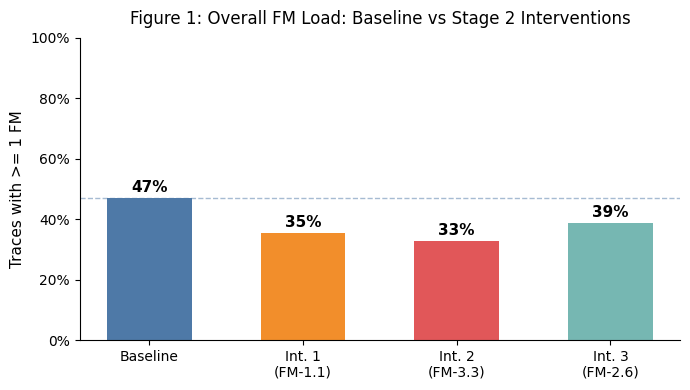

In [170]:
import matplotlib.pyplot as plt

runs_fig1 = [
    ('Baseline',                       df_base),
    ('Int. 1\n(FM-1.1)',     load_run(INTERVENTIONS[1][1], 'int_1.1')),
    ('Int. 2\n(FM-3.3)',      load_run(INTERVENTIONS[2][1], 'int_3.3')),
    ('Int. 3\n(FM-2.6)', load_run(INTERVENTIONS[0][1], 'int_2.6')),
]

labels   = [r[0] for r in runs_fig1]
fm_loads = [r[1][FM_CODES].any(axis=1).mean() for r in runs_fig1]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
bars = ax.bar(labels, fm_loads, color=colors, width=0.55)

for bar, val in zip(bars, fm_loads):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.0%}',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )

ax.set_ylabel('Traces with >= 1 FM', fontsize=11)
ax.set_title('Figure 1: Overall FM Load: Baseline vs Stage 2 Interventions', fontsize=12, pad=10)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(fm_loads[0], color='#4e79a7', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figure1_fm_load_stage2.png', dpi=150, bbox_inches='tight')
plt.show()

In [171]:
import numpy as np

paired_ctx = pair_runs(df_base_ctx, df_s3_ctx)
n_paired   = len(paired_ctx)

PURP_BG = '#e8daef'; PURP_FG = '#6c3483'
GREEN_BG = '#d6f0e0'; GREEN_FG = '#145a32'
RED_BG  = '#fde8e4'; RED_FG  = '#922b21'
ALT_BG  = '#f4f6f8'; ACC_BG  = '#eaf0fb'

def _fp2(p):
    if np.isnan(p): return '—'
    if p < 0.001:   return '< 0.001'
    return f'{p:.3f}'

def _fd2(d):
    pp = d * 100
    return f'+{pp:.1f} pp' if pp >= 0 else f'{pp:.1f} pp'

rows_s3 = []

bv = paired_ctx['correct_base'].astype(float).values
iv = paired_ctx['correct_int'].astype(float).values
_, _, _, p_acc, _ = mcnemar_test(bv, iv)
rows_s3.append({
    'Metric / Failure Mode': 'Accuracy',
    'Baseline': f'{bv.mean():.1%}',
    'Stage 3':  f'{iv.mean():.1%}',
    'Δ (pp)':   _fd2(iv.mean() - bv.mean()),
    'p-value':  _fp2(p_acc),
    '_fm':    None,
    '_delta': iv.mean() - bv.mean(),
    '_i':     0,
})

for i, fm in enumerate(FM_CODES, 1):
    bv = paired_ctx[f'{fm}_base'].astype(float).values
    iv = paired_ctx[f'{fm}_int'].astype(float).values
    _, _, _, p_fm, _ = mcnemar_test(bv, iv)
    rows_s3.append({
        'Metric / Failure Mode': f'FM-{fm}  {FM_NAMES[fm]}',
        'Baseline': f'{bv.mean():.1%}',
        'Stage 3':  f'{iv.mean():.1%}',
        'Δ (pp)':   _fd2(iv.mean() - bv.mean()),
        'p-value':  _fp2(p_fm),
        '_fm':    fm,
        '_delta': iv.mean() - bv.mean(),
        '_i':     i,
    })

tbl_s3_full = pd.DataFrame(rows_s3)

def _hl_s3_full(row):
    fm  = row['_fm']
    idx = row['_i']
    bg  = (ACC_BG  if fm is None else
           PURP_BG if fm == '1.1' else
           GREEN_BG if fm == '3.3' else
           RED_BG  if fm == '2.6' else
           ALT_BG  if idx % 2 == 0 else 'white')
    bg_css = f'background-color: {bg}'
    result = {col: bg_css for col in row.index}

    if fm == '1.1':
        result['Metric / Failure Mode'] = f'{bg_css}; color: {PURP_FG}; font-weight: bold'
    elif fm == '3.3':
        result['Metric / Failure Mode'] = f'{bg_css}; color: {GREEN_FG}; font-weight: bold'
    elif fm == '2.6':
        result['Metric / Failure Mode'] = f'{bg_css}; color: {RED_FG}; font-weight: bold'

    if fm is not None:
        d = row['_delta']
        if d < -0.04:
            result['Δ (pp)'] = f'{bg_css}; color: {GREEN_FG}; font-weight: bold'
        elif d > 0.04:
            result['Δ (pp)'] = f'{bg_css}; color: {RED_FG}; font-weight: bold'

    return pd.Series(result)

display(
    tbl_s3_full.style
    .apply(_hl_s3_full, axis=1)
    .hide(axis='index')
    .hide(['_fm', '_delta', '_i'], axis='columns')
    .set_caption(
        f'Baseline (with-ctx) vs Stage 3 (with-ctx) — alle FMs  '
        f'(n = {n_paired} paired tasks)'
    )
    .set_properties(**{'text-align': 'right'},
                    subset=['Baseline', 'Stage 3', 'Δ (pp)', 'p-value'])
    .set_properties(**{'text-align': 'left'}, subset=['Metric / Failure Mode'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#1e2d3d'),
                   ('color', 'white'), ('font-weight', 'bold')]},
    ])
)

Metric / Failure Mode,Baseline,Stage 3,Δ (pp),p-value
Accuracy,68.1%,70.2%,+2.1 pp,1.000
FM-1.1 Disobey Task Specification,12.8%,6.4%,-6.4 pp,0.453
FM-1.2 Disobey Role Specification,0.0%,0.0%,+0.0 pp,—
FM-1.3 Step Repetition,2.1%,4.3%,+2.1 pp,1.000
FM-1.4 Loss of Conversation History,0.0%,2.1%,+2.1 pp,1.000
FM-1.5 Unaware of Termination Conditions,0.0%,2.1%,+2.1 pp,1.000
FM-2.1 Conversation Reset,0.0%,0.0%,+0.0 pp,—
FM-2.2 Fail to Ask for Clarification,4.3%,0.0%,-4.3 pp,0.500
FM-2.3 Task Derailment,2.1%,2.1%,+0.0 pp,1.000
FM-2.4 Information Withholding,2.1%,0.0%,-2.1 pp,1.000


In [172]:
SLIDE_FMS = ['1.1', '2.6', '3.3']

paired_ctx = pair_runs(df_base_ctx, df_s3_ctx)
n_paired   = len(paired_ctx)

rows_slide = []

bv = paired_ctx['correct_base'].astype(float).values
iv = paired_ctx['correct_int'].astype(float).values
_, _, _, p_acc, _ = mcnemar_test(bv, iv)
rows_slide.append({
    'Metric / Failure Mode': 'Accuracy',
    'Baseline': f'{bv.mean():.1%}',
    'Stage 3':  f'{iv.mean():.1%}',
    'Δ (pp)':   _fd2(iv.mean() - bv.mean()),
    'p-value':  _fp2(p_acc),
    '_fm':    None,
    '_delta': iv.mean() - bv.mean(),
})

for fm in SLIDE_FMS:
    bv = paired_ctx[f'{fm}_base'].astype(float).values
    iv = paired_ctx[f'{fm}_int'].astype(float).values
    _, _, _, p_fm, _ = mcnemar_test(bv, iv)
    rows_slide.append({
        'Metric / Failure Mode': f'FM-{fm}  {FM_NAMES[fm]}',
        'Baseline': f'{bv.mean():.1%}',
        'Stage 3':  f'{iv.mean():.1%}',
        'Δ (pp)':   _fd2(iv.mean() - bv.mean()),
        'p-value':  _fp2(p_fm),
        '_fm':    fm,
        '_delta': iv.mean() - bv.mean(),
    })

tbl_slide = pd.DataFrame(rows_slide)

def _hl_slide(row):
    fm = row['_fm']
    bg = (ACC_BG   if fm is None else
          GREEN_BG if fm == '3.3' else
          RED_BG   if fm == '2.6' else 'white')
    bg_css = f'background-color: {bg}'
    result = {col: bg_css for col in row.index}

    if fm == '3.3':
        result['Metric / Failure Mode'] = f'{bg_css}; color: {GREEN_FG}; font-weight: bold'
    elif fm == '2.6':
        result['Metric / Failure Mode'] = f'{bg_css}; color: {RED_FG}; font-weight: bold'

    if fm is not None:
        d = row['_delta']
        if d < -0.04:
            result['Δ (pp)'] = f'{bg_css}; color: {GREEN_FG}; font-weight: bold'
        elif d > 0.04:
            result['Δ (pp)'] = f'{bg_css}; color: {RED_FG}; font-weight: bold'

    return pd.Series(result)

display(
    tbl_slide.style
    .apply(_hl_slide, axis=1)
    .hide(axis='index')
    .hide(['_fm', '_delta'], axis='columns')
    .set_caption(
        f'Baseline (with-ctx) vs Stage 3 (with-ctx) — target FMs  '
        f'(n = {n_paired} paired tasks)'
    )
    .set_properties(**{'text-align': 'right'},
                    subset=['Baseline', 'Stage 3', 'Δ (pp)', 'p-value'])
    .set_properties(**{'text-align': 'left'}, subset=['Metric / Failure Mode'])
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '1.05em'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('background-color', '#1e2d3d'),
                   ('color', 'white'), ('font-weight', 'bold')]},
    ])
)

Metric / Failure Mode,Baseline,Stage 3,Δ (pp),p-value
Accuracy,68.1%,70.2%,+2.1 pp,1.000
FM-1.1 Disobey Task Specification,12.8%,6.4%,-6.4 pp,0.453
FM-2.6 Action-Reasoning Mismatch,8.5%,19.1%,+10.6 pp,0.180
FM-3.3 Weak Verification,14.9%,2.1%,-12.8 pp,0.031


---
## Figure 2: Overall FM Load: Stage 1 (with context) vs Stage 3 (with context)

Proportion of traces with ≥ 1 failure mode — Baseline and Stage 3, both judged with the context note.

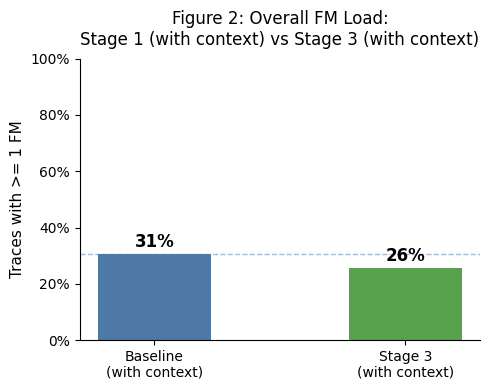

In [173]:
import matplotlib.pyplot as plt

runs_fig2 = [
    ('Baseline\n(with context)', df_base_ctx),
    ('Stage 3\n(with context)', df_s3_ctx),
]

labels_fig2   = [r[0] for r in runs_fig2]
fm_loads_fig2 = [r[1][FM_CODES].any(axis=1).mean() for r in runs_fig2]

fig, ax = plt.subplots(figsize=(5, 4))
colors_fig2 = ['#4e79a7', '#59a14f']
bars = ax.bar(labels_fig2, fm_loads_fig2, color=colors_fig2, width=0.45)

for bar, val in zip(bars, fm_loads_fig2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.0%}',
        ha='center', va='bottom', fontsize=12, fontweight='bold',
    )

ax.set_ylabel('Traces with >= 1 FM', fontsize=11)
ax.set_title(
    'Figure 2: Overall FM Load:\nStage 1 (with context) vs Stage 3 (with context)',
    fontsize=12, pad=10,
)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(fm_loads_fig2[0], color='#4e79a7', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figure2_fm_load_stage3_ctx.png', dpi=150, bbox_inches='tight')
plt.show()